# **Adult Income Classification**

## **Obtener la data**

In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd

adult = fetch_openml(name='adult', version=2, as_frame=True)
X = adult.data.copy()
y = adult.target.copy()

print(adult.DESCR[:2000])

**Author**: Ronny Kohavi and Barry Becker  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/Adult) - 1996  
**Please cite**: Ron Kohavi, "Scaling Up the Accuracy of Naive-Bayes Classifiers: a Decision-Tree Hybrid", Proceedings of the Second International Conference on Knowledge Discovery and Data Mining, 1996  

Prediction task is to determine whether a person makes over 50K a year. Extraction was done by Barry Becker from the 1994 Census database. A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))

This is the original version from the UCI repository, with training and test sets merged.

### Variable description

Variables are all self-explanatory except __fnlwgt__. This is a proxy for the demographic background of the people: "People with similar demographic characteristics should have similar weights". This similarity-statement is not transferable across the 51 different states.

Description f

## **Variables**

In [2]:
X.columns.to_list()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country']

In [3]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


Asignamos el target binario a formato 0 / 1

In [4]:
y = (y == '>50K').astype(int)
y.value_counts(normalize=True)

class
0    0.760718
1    0.239282
Name: proportion, dtype: float64

## **Feature Engineer**

In [5]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


### **Distribucion de target: y**

<Axes: >

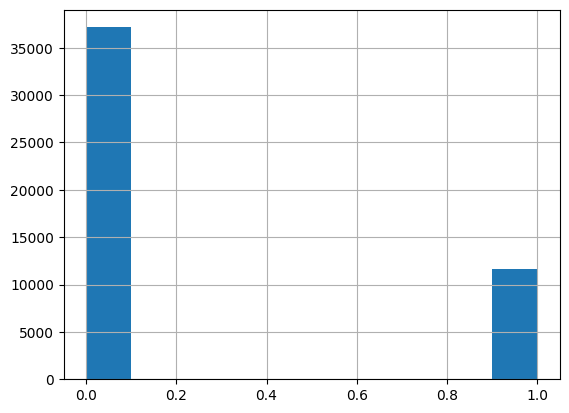

In [6]:
y.hist()

In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


## **EDA**

Analisis de variables, relaciones importantes y creación de nuevas variables

In [8]:
X.describe(include='all').T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,46043,8,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,46033,14,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

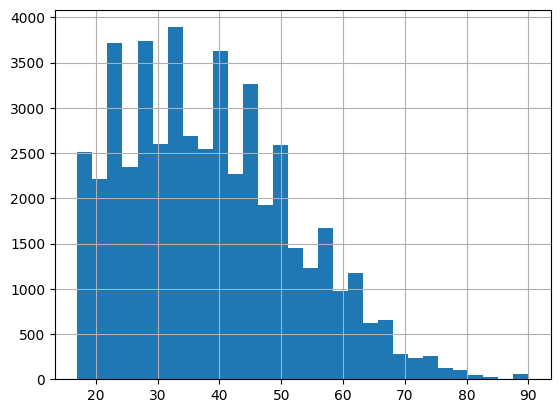

In [9]:
X['age'].hist(bins=30)

In [10]:
X['target'] = y

<Axes: >

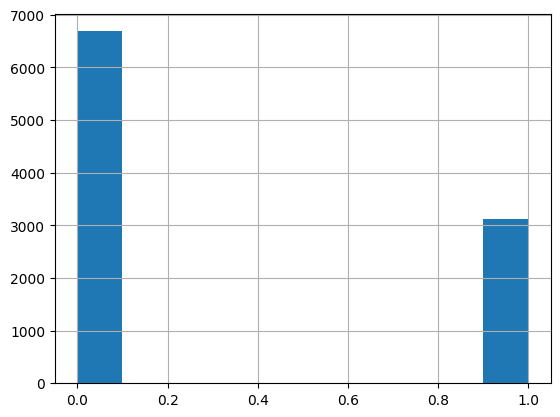

In [11]:
X[X['age'] > 50]['target'].hist()

### **Crear variables**

In [12]:
import numpy as np

X['capital_balance'] = X['capital-gain'] - X['capital-loss']
X['hours_per_week_group'] = pd.cut(
    X['hours-per-week'],
    bins=[0, 25, 40, 60, 100],
    labels=['part_time', 'standard', 'extended', 'very_high'],
    include_lowest=True
)
X['is_married'] = np.where(
    X['marital-status'].astype(str).str.contains('Married', case=False, na=False),
    1,
    0
)
X['has_capital_change'] = np.where(
    (X['capital-gain'] > 0) | (X['capital-loss'] > 0),
    1,
    0
)
X['education_num_per_age'] = X['education-num'] / X['age']
X[['capital_balance', 'hours_per_week_group', 'is_married', 'has_capital_change', 'education_num_per_age']].head()

,capital_balance,hours_per_week_group,is_married,has_capital_change,education_num_per_age
0,0,standard,1,0,0.280000
1,0,extended,1,0,0.236842
2,0,standard,1,0,0.428571
3,7688,standard,1,1,0.227273
4,0,standard,1,0,0.555556


In [13]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target,capital_balance,hours_per_week_group,is_married,has_capital_change,education_num_per_age
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,0,standard,1,0,0.280000
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,0,extended,1,0,0.236842
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0,standard,1,0,0.428571
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,7688,standard,1,1,0.227273
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,0,standard,1,0,0.555556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0,0,standard,1,0,0.444444
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1,0,standard,1,0,0.225000
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0,0,standard,0,0,0.155172
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0,0,part_time,1,0,0.409091


## **Feature Engineer**

In [14]:
len(X)

48842

In [15]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    48842 non-null  int64   
 1   workclass              46043 non-null  category
 2   fnlwgt                 48842 non-null  int64   
 3   education              48842 non-null  category
 4   education-num          48842 non-null  int64   
 5   marital-status         48842 non-null  category
 6   occupation             46033 non-null  category
 7   relationship           48842 non-null  category
 8   race                   48842 non-null  category
 9   sex                    48842 non-null  category
 10  capital-gain           48842 non-null  int64   
 11  capital-loss           48842 non-null  int64   
 12  hours-per-week         48842 non-null  int64   
 13  native-country         47985 non-null  category
 14  target                 48842 non-null  int64   
 

In [16]:
X.isna().sum().sort_values(ascending=False).head(15)

occupation              2809
workclass               2799
native-country           857
age                        0
capital-loss               0
has_capital_change         0
is_married                 0
hours_per_week_group       0
capital_balance            0
target                     0
hours-per-week             0
capital-gain               0
sex                        0
race                       0
relationship               0
dtype: int64

## 1. Missing data fill

In [17]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

In [18]:
imputer_constant = SimpleImputer(strategy='constant', fill_value='missing')

In [19]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target,capital_balance,hours_per_week_group,is_married,has_capital_change,education_num_per_age
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,0,standard,1,0,0.280000
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,0,extended,1,0,0.236842
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0,standard,1,0,0.428571
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,7688,standard,1,1,0.227273
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,0,standard,1,0,0.555556


In [22]:
X_imputed_demo = X.copy()
cat_demo_cols = X_imputed_demo.select_dtypes(include=['object', 'category']).columns.tolist() + ['hours_per_week_group']
num_demo_cols = X_imputed_demo.select_dtypes(exclude=['object', 'category']).drop(columns='target').columns.tolist()

X_imputed_demo[cat_demo_cols] = imputer_constant.fit_transform(X_imputed_demo[cat_demo_cols])
X_imputed_demo[num_demo_cols] = SimpleImputer(strategy='median').fit_transform(X_imputed_demo[num_demo_cols])
X_imputed_demo.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target,capital_balance,hours_per_week_group,is_married,has_capital_change,education_num_per_age
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,0,0.0,standard,1.0,0.0,0.280000
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,0,0.0,extended,1.0,0.0,0.236842
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,1,0.0,standard,1.0,0.0,0.428571
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,1,7688.0,standard,1.0,1.0,0.227273
4,18.0,missing,103497.0,Some-college,10.0,Never-married,missing,Own-child,White,Female,0.0,0.0,30.0,United-States,0,0.0,standard,1.0,0.0,0.555556


## One-hot or codification strings

In [23]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

nominal_cols = ['workclass', 'education', 'occupation']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
nominal_encoded = ohe.fit_transform(X[nominal_cols])
nominal_encoded[:3]

array([[0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0.]])

In [24]:
ohe.get_feature_names_out(nominal_cols)

array(['workclass_Local-gov', 'workclass_Never-worked',
       'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'workclass_nan', 'education_11th',
       'education_12th', 'education_1st-4th', 'education_5th-6th',
       'education_7th-8th', 'education_9th', 'education_Assoc-acdm',
       'education_Assoc-voc', 'education_Bachelors',
       'education_Doctorate', 'education_HS-grad', 'education_Masters',
       'education_Preschool', 'education_Prof-school',
       'education_Some-college', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specialty',
       'occupation_Protective-serv', 'occupation_Sales',
       'occupation_Tech-support', 'occupation_Transport-moving',

In [25]:
nominal_df = pd.DataFrame(
    nominal_encoded,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X.index
)
nominal_df.head()

,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_nan,education_11th,education_12th,...,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_nan
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [26]:
pd.concat([X[nominal_cols].head(), nominal_df.head()], axis=1)

,workclass,education,occupation,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,...,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_nan
0,Private,11th,Machine-op-inspct,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Private,HS-grad,Farming-fishing,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Local-gov,Assoc-acdm,Protective-serv,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,Private,Some-college,Machine-op-inspct,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NaN,Some-college,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [27]:
## Lo de arriba es explicativo, luego lo metemos dentro del pipeline
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target,capital_balance,hours_per_week_group,is_married,has_capital_change,education_num_per_age
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,0,standard,1,0,0.280000
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,0,extended,1,0,0.236842
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0,standard,1,0,0.428571
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,7688,standard,1,1,0.227273
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,0,standard,1,0,0.555556


## Escalamiento

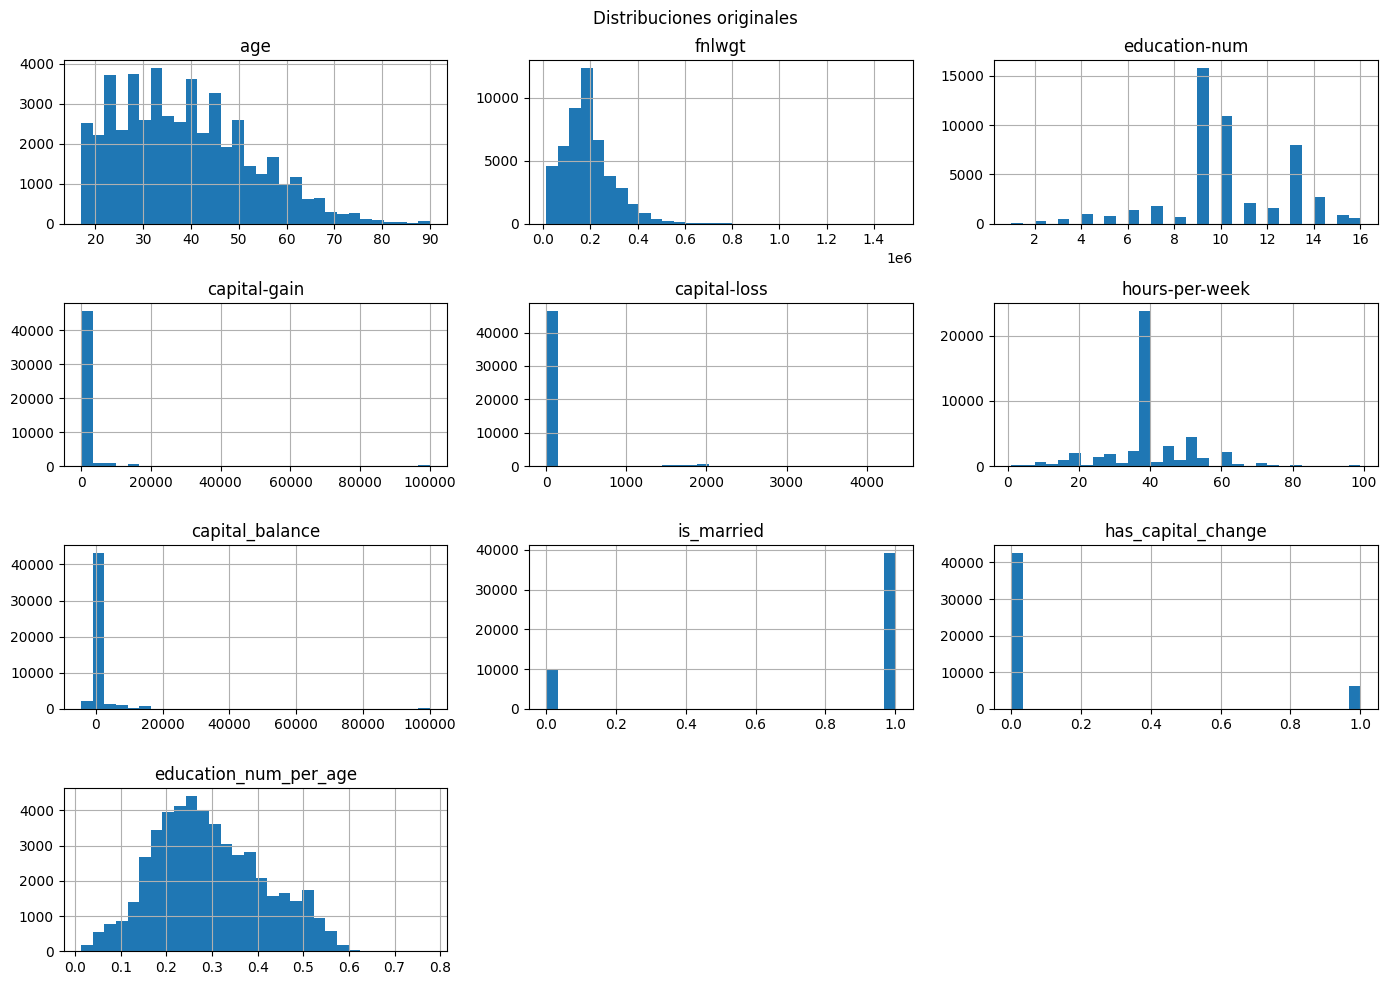

In [28]:
import matplotlib.pyplot as plt

X.select_dtypes(exclude=['object', 'category']).drop(columns='target').hist(figsize=(14, 10), bins=30)
plt.suptitle('Distribuciones originales')
plt.tight_layout()
plt.show()

In [29]:
scaler = StandardScaler()
X_scaled_demo = scaler.fit_transform(X.select_dtypes(exclude=['object', 'category']).drop(columns='target').fillna(0))
X_scaled_demo[:3]

array([[-0.99512893,  0.35167453, -1.19725891, -0.14480353, -0.2171271 ,
        -0.03408696, -0.13264248,  0.49720241, -0.38541914, -0.11690317],
       [-0.04694151, -0.94552415, -0.41933527, -0.14480353, -0.2171271 ,
         0.77292975, -0.13264248,  0.49720241, -0.38541914, -0.48001716],
       [-0.77631645,  1.3947231 ,  0.74755018, -0.14480353, -0.2171271 ,
        -0.03408696, -0.13264248,  0.49720241, -0.38541914,  1.1331199 ]])

In [30]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target,capital_balance,hours_per_week_group,is_married,has_capital_change,education_num_per_age
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,0,standard,1,0,0.280000
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,0,extended,1,0,0.236842
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0,standard,1,0,0.428571
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,7688,standard,1,1,0.227273
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,0,standard,1,0,0.555556


## Implementacion punta a punta

In [31]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [32]:
X.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'target', 'capital_balance', 'hours_per_week_group', 'is_married',
       'has_capital_change', 'education_num_per_age'],
      dtype='str')

In [33]:
cat_cols = [
    'workclass', 'education', 'marital-status', 'occupation', 'relationship',
    'race', 'sex', 'native-country', 'hours_per_week_group'
]

num_cols = [col for col in X.columns if col not in cat_cols + ['target']]

numeric_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [34]:
preprocess_simple = ColumnTransformer(transformers=[
    ('num', numeric_simple, num_cols),
    ('cat', categorical_simple, cat_cols)
])

In [35]:
model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=3000))
])

In [36]:
X_dropped = X.drop(columns='target')
y = X['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_dropped,
    y,
    test_size=0.25,
    stratify=y,
    random_state=12345
)

In [37]:
X_train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,capital_balance,hours_per_week_group,is_married,has_capital_change,education_num_per_age
41022,25,Self-emp-not-inc,259299,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,3103,0,50,United-States,3103,extended,1,1,0.400000
3728,61,Private,132529,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,0,standard,1,0,0.098361
42415,48,Private,67725,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,0,extended,1,0,0.270833
38678,49,Private,168262,10th,6,Divorced,Other-service,Not-in-family,White,Male,0,0,48,United-States,0,extended,0,0,0.122449
29148,35,Federal-gov,133935,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,0,standard,1,0,0.371429


In [38]:
X_test.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,capital_balance,hours_per_week_group,is_married,has_capital_change,education_num_per_age
45951,34,Private,100593,Some-college,10,Divorced,Prof-specialty,Unmarried,White,Female,0,0,6,United-States,0,part_time,0,0,0.294118
23717,21,Private,246207,Some-college,10,Never-married,Adm-clerical,Own-child,Black,Female,0,0,20,United-States,0,part_time,1,0,0.476190
9928,35,Self-emp-not-inc,280570,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,35,United-States,0,standard,1,0,0.257143
27752,22,Private,110946,Some-college,10,Never-married,Other-service,Not-in-family,White,Female,0,0,40,United-States,0,standard,1,0,0.454545
13974,29,Private,212588,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,0,standard,1,0,0.310345


In [39]:
model_simple.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [40]:
model_simple.predict(X_test)

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


array([0, 0, 0, ..., 0, 0, 0], shape=(12211,))

In [41]:
model_simple.predict_proba(X_test)

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


array([[9.90198039e-01, 9.80196056e-03],
       [9.99243276e-01, 7.56724081e-04],
       [6.85763127e-01, 3.14236873e-01],
       ...,
       [8.11991288e-01, 1.88008712e-01],
       [9.92088034e-01, 7.91196625e-03],
       [5.18186293e-01, 4.81813707e-01]], shape=(12211, 2))

In [42]:
model_simple.predict_proba(X_test)[:, 1]

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


array([0.00980196, 0.00075672, 0.31423687, ..., 0.18800871, 0.00791197,
       0.48181371], shape=(12211,))

In [43]:
pred_proba_simple = model_simple.predict_proba(X_test)[:, 1]
print('AUC simple imputer:', round(roc_auc_score(y_test, pred_proba_simple), 4))

AUC simple imputer: 0.9135


/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


# **1. Interpretacion Metricas**

In [44]:
y_pred = model_simple.predict(X_test)
y_pred_proba = model_simple.predict_proba(X_test)[:, 1]

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Accuracy: 0.8575
Precision: 0.7506
Recall: 0.6057
F1: 0.6705
AUC: 0.9135


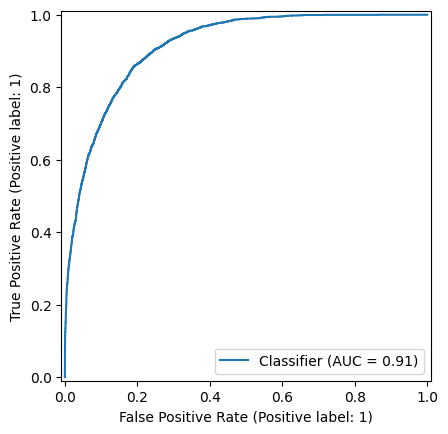

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('Accuracy:', round(acc, 4))
print('Precision:', round(prec, 4))
print('Recall:', round(rec, 4))
print('F1:', round(f1, 4))
print('AUC:', round(auc, 4))

RocCurveDisplay.from_predictions(y_test, y_pred_proba)

In [46]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,8701,588
Real 1,1152,1770


In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      9289
           1       0.75      0.61      0.67      2922

    accuracy                           0.86     12211
   macro avg       0.82      0.77      0.79     12211
weighted avg       0.85      0.86      0.85     12211



# **2. Oversampling**

In [48]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


model_oversampled = ImbPipeline(steps=[
    ('prep', preprocess_simple),
    ('oversample', SMOTE(random_state=52)),
    ('clf', LogisticRegression(max_iter=3000))
])

model_oversampled.fit(X_train, y_train)

,steps,"[('prep', ...), ('oversample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The gi

In [49]:
y_pred_oversampled = model_oversampled.predict(X_test)
y_pred_proba_oversampled = model_oversampled.predict_proba(X_test)[:, 1]

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [50]:
acc = accuracy_score(y_test, y_pred_oversampled)
prec = precision_score(y_test, y_pred_oversampled)
rec = recall_score(y_test, y_pred_oversampled)
f1 = f1_score(y_test, y_pred_oversampled)
auc = roc_auc_score(y_test, y_pred_proba_oversampled)

print('Accuracy:', round(acc, 4))
print('Precision:', round(prec, 4))
print('Recall:', round(rec, 4))
print('F1:', round(f1, 4))
print('AUC:', round(auc, 4))

Accuracy: 0.817
Precision: 0.5798
Recall: 0.8542
F1: 0.6907
AUC: 0.913


In [51]:
cm = confusion_matrix(y_test, y_pred_oversampled)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,7480,1809
Real 1,426,2496


In [52]:
print(classification_report(y_test, y_pred_oversampled))

              precision    recall  f1-score   support

           0       0.95      0.81      0.87      9289
           1       0.58      0.85      0.69      2922

    accuracy                           0.82     12211
   macro avg       0.76      0.83      0.78     12211
weighted avg       0.86      0.82      0.83     12211



In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      9289
           1       0.75      0.61      0.67      2922

    accuracy                           0.86     12211
   macro avg       0.82      0.77      0.79     12211
weighted avg       0.85      0.86      0.85     12211



# **3. Implementar CV**

In [54]:
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)

scores = cross_val_score(
    model_simple,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print('CV scores:', scores)
print('Mean AUC:', scores.mean())

CV scores: [0.90931748 0.90983312 0.91549111 0.91313714 0.91194844]
Mean AUC: 0.9119454591943814


In [55]:
y_pred_kfold = cross_val_predict(model_simple, X_test, y_test, cv=cv)
y_pred_kfold[:10]

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0])

In [56]:
print(classification_report(y_test, y_pred_kfold))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      9289
           1       0.74      0.61      0.67      2922

    accuracy                           0.86     12211
   macro avg       0.81      0.77      0.79     12211
weighted avg       0.85      0.86      0.85     12211



In [57]:
print('1er modelo')
print(classification_report(y_test, y_pred))

1er modelo
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      9289
           1       0.75      0.61      0.67      2922

    accuracy                           0.86     12211
   macro avg       0.82      0.77      0.79     12211
weighted avg       0.85      0.86      0.85     12211



# **4. Feature Importance**

Extraemos los coeficientes del modelo

In [58]:
model_simple.fit(X_train, y_train)

feature_names = model_simple.named_steps['prep'].get_feature_names_out()
coefficients = model_simple.named_steps['clf'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

feature_importance.head(20)

,feature,coefficient,abs_coefficient
3,num__capital-gain,2.356116,2.356116
6,num__capital_balance,2.306989,2.306989
2,num__education-num,1.427685,1.427685
9,num__education_num_per_age,-1.421243,1.421243
35,cat__marital-status_Never-married,-1.360414,1.360414
63,cat__native-country_Columbia,-1.280624,1.280624
55,cat__relationship_Wife,1.208724,1.208724
100,cat__hours_per_week_group_part_time,-1.090612,1.090612
65,cat__native-country_Dominican-Republic,-1.063555,1.063555
34,cat__marital-status_Married-spouse-absent,-1.044171,1.044171


# **4.1 Shap values**

In [59]:
import shap


X_train_transformed = model_simple.named_steps['prep'].transform(X_train)
X_test_transformed = model_simple.named_steps['prep'].transform(X_test)
feature_names = model_simple.named_steps['prep'].get_feature_names_out()

if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_test_transformed_dense = X_test_transformed

explainer = shap.LinearExplainer(
    model_simple.named_steps['clf'],
    X_test_transformed_dense,
    feature_names=feature_names
)
shap_values = explainer(X_test_transformed_dense)

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Summary plot

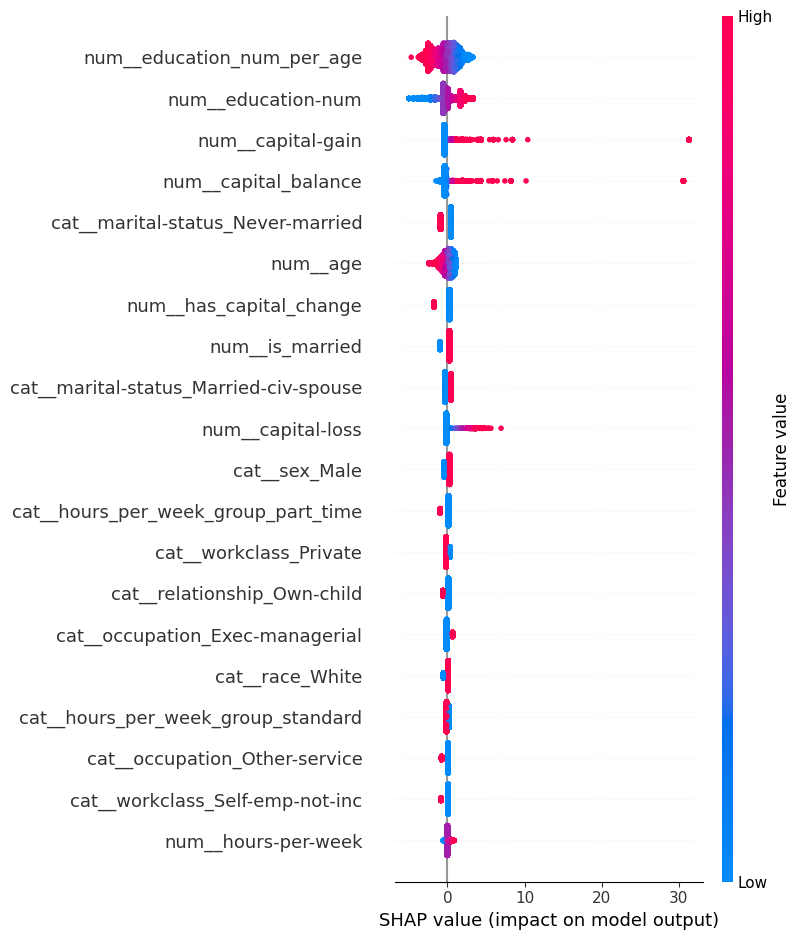

In [60]:
shap.summary_plot(shap_values.values, X_test_transformed_dense, feature_names=feature_names)

## Bar plot

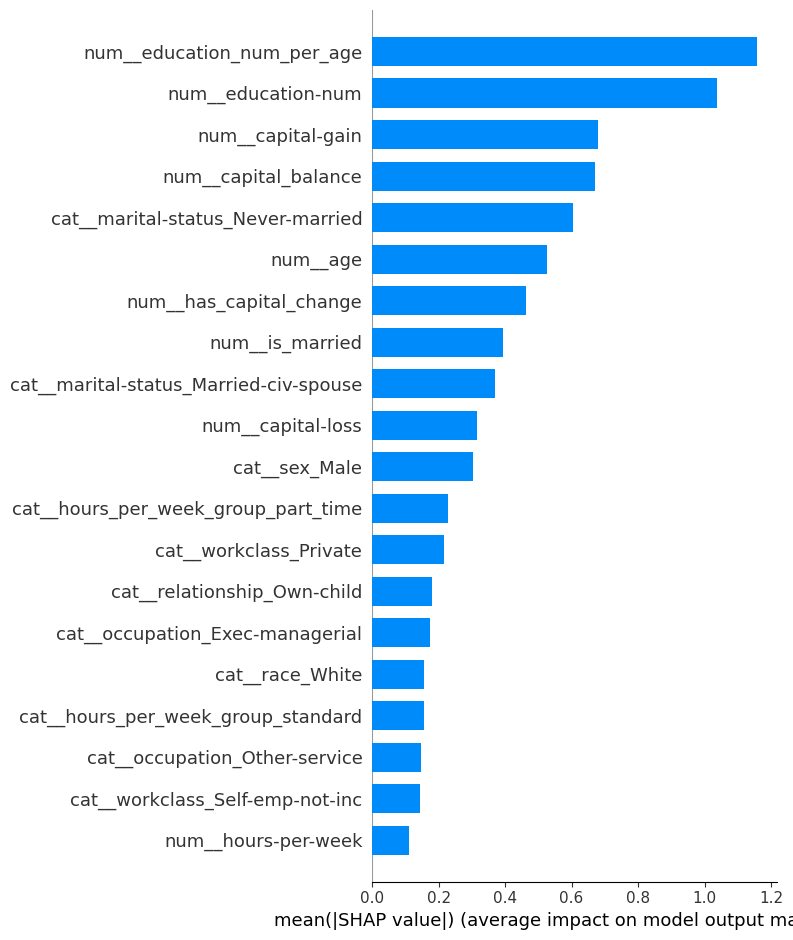

In [61]:
shap.summary_plot(shap_values.values, X_test_transformed_dense, feature_names=feature_names, plot_type='bar')

## Local explanation

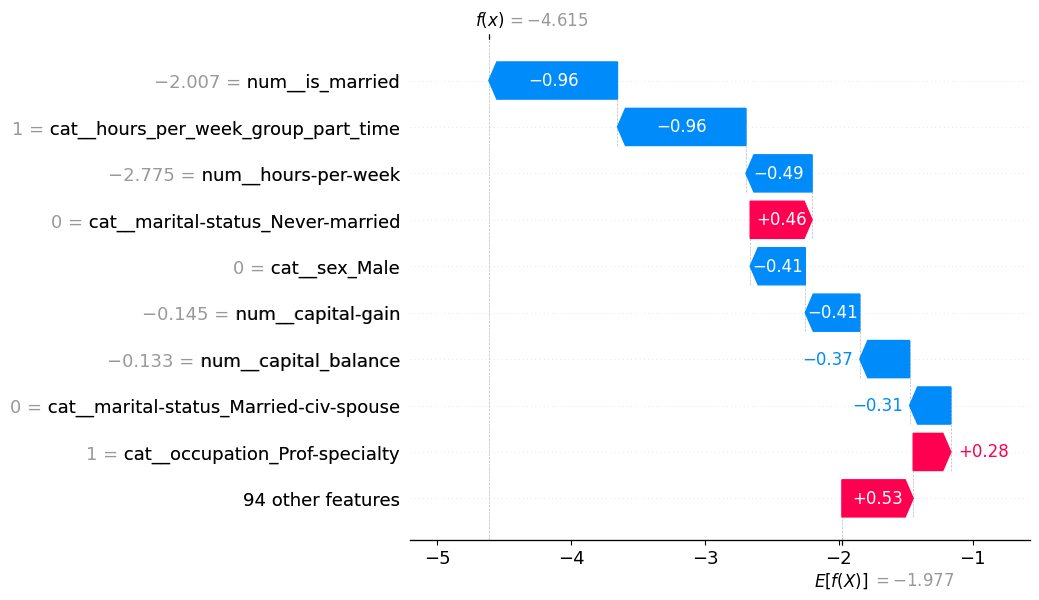

In [62]:
row_idx = 0
shap.plots.waterfall(shap_values[row_idx])

# **5. Jugar con otros modelos**

En esta sección vamos a probar modelos distintos a la regresión logística para comparar desempeño.

## **5.1 Modelos a probar**

### **Random Forest**
Random Forest combina muchos árboles de decisión entrenados sobre muestras distintas.

### **XGBoost**
XGBoost suele capturar relaciones no lineales y combinaciones complejas entre variables.

In [63]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold

## **5.2 Función para evaluar modelos**

In [64]:
def evaluate_model(name, fitted_model, X_eval, y_eval, cv_scores=None):
    y_pred_local = fitted_model.predict(X_eval)
    y_pred_proba_local = fitted_model.predict_proba(X_eval)[:, 1]

    results = {
        'model': name,
        'accuracy': accuracy_score(y_eval, y_pred_local),
        'precision': precision_score(y_eval, y_pred_local),
        'recall': recall_score(y_eval, y_pred_local),
        'f1': f1_score(y_eval, y_pred_local),
        'auc_test': roc_auc_score(y_eval, y_pred_proba_local),
    }

    if cv_scores is not None:
        results['auc_cv_mean'] = cv_scores.mean()
        results['auc_cv_std'] = cv_scores.std()

    return results

## **5.3 Random Forest**

In [65]:
rf_model = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=52,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')
rf_results = evaluate_model('Random Forest', rf_model, X_test, y_test, rf_cv_scores)
rf_results

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


{'model': 'Random Forest',
 'accuracy': 0.856932274179019,
 'precision': 0.7986781901372648,
 'recall': 0.5376454483230664,
 'f1': 0.6426672121088157,
 'auc_test': 0.9136309062355369,
 'auc_cv_mean': np.float64(0.9114689879837963),
 'auc_cv_std': np.float64(0.0027911861308622153)}

## **5.4 XGBoost**

In [66]:
xgb_model = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=52
    ))
])

xgb_model.fit(X_train, y_train)
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
xgb_results = evaluate_model('XGBoost', xgb_model, X_test, y_test, xgb_cv_scores)
xgb_results

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


{'model': 'XGBoost',
 'accuracy': 0.8711817213987388,
 'precision': 0.7772297575010275,
 'recall': 0.6471594798083504,
 'f1': 0.7062558356676004,
 'auc_test': 0.9278194885665845,
 'auc_cv_mean': np.float64(0.9250673723072017),
 'auc_cv_std': np.float64(0.00275594107730703)}

## **5.5 Comparación contra el primer modelo**

In [68]:
baseline_results = evaluate_model('Logistic Regression', model_simple, X_test, y_test, scores)
comparison_df = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results
]).round(4)

comparison_df.sort_values('f1', ascending=False)

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
2,XGBoost,0.8712,0.7772,0.6472,0.7063,0.9278,0.9251,0.0028
0,Logistic Regression,0.8575,0.7506,0.6057,0.6705,0.9135,0.9119,0.0023
1,Random Forest,0.8569,0.7987,0.5376,0.6427,0.9136,0.9115,0.0028


## **6. Optimización con Optuna**

Ahora usamos **Optuna** para buscar mejores hiperparámetros.

In [69]:
import optuna


optuna.__version__

'4.8.0'

### **6.1 Optuna para Random Forest**

In [70]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 18),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }

    rf_trial_model = Pipeline(steps=[
        ('prep', preprocess_simple),
        ('clf', RandomForestClassifier(**params, random_state=52, n_jobs=-1))
    ])

    scores_trial = cross_val_score(rf_trial_model, X_train, y_train, cv=cv, scoring='f1')
    return scores_trial.mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=15)
study_rf.best_params

[I 2026-04-22 11:12:44,992] A new study created in memory with name: no-name-e97a4b72-79c5-41ba-92e0-6585defe9b6a
[I 2026-04-22 11:12:56,868] Trial 0 finished with value: 0.645370115110711 and parameters: {'n_estimators': 433, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.645370115110711.
[I 2026-04-22 11:13:00,851] Trial 1 finished with value: 0.6366533644550578 and parameters: {'n_estimators': 181, 'max_depth': 14, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.645370115110711.
[I 2026-04-22 11:13:05,165] Trial 2 finished with value: 0.5081097558949372 and parameters: {'n_estimators': 217, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.645370115110711.
[I 2026-04-22 11:13:13,839] Trial 3 finished with value: 0.6620934770416086 and parameters: {'n_estimators': 213, 'max_depth': 15, 'min_

{'n_estimators': 345,
 'max_depth': 16,
 'min_samples_split': 7,
 'min_samples_leaf': 1,
 'max_features': 'sqrt'}

In [71]:
rf_best_model = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', RandomForestClassifier(**study_rf.best_params, random_state=52, n_jobs=-1))
])

rf_best_model.fit(X_train, y_train)
rf_best_cv_scores = cross_val_score(rf_best_model, X_train, y_train, cv=cv, scoring='f1')
rf_best_results = evaluate_model('Random Forest + Optuna', rf_best_model, X_test, y_test, rf_best_cv_scores)
rf_best_results

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


{'model': 'Random Forest + Optuna',
 'accuracy': 0.8618458766685775,
 'precision': 0.7919621749408984,
 'recall': 0.5732375085557837,
 'f1': 0.6650784196942625,
 'auc_test': 0.920353491935034,
 'auc_cv_mean': np.float64(0.6637812378651244),
 'auc_cv_std': np.float64(0.01013554172995803)}

### **6.2 Optuna para XGBoost**

In [72]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 52
    }

    xgb_trial_model = Pipeline(steps=[
        ('prep', preprocess_simple),
        ('clf', XGBClassifier(**params))
    ])

    scores_trial = cross_val_score(xgb_trial_model, X_train, y_train, cv=cv, scoring='f1')
    return scores_trial.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=15)
study_xgb.best_params

[I 2026-04-22 11:14:51,482] A new study created in memory with name: no-name-05960dd2-2ca5-4c72-a75e-f408fb82f041
[I 2026-04-22 11:14:54,080] Trial 0 finished with value: 0.7025976966073592 and parameters: {'n_estimators': 392, 'learning_rate': 0.07437959419161973, 'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.9840603403915525, 'colsample_bytree': 0.6065987341033, 'gamma': 2.286254241959786, 'reg_lambda': 0.1856842480661452}. Best is trial 0 with value: 0.7025976966073592.
[I 2026-04-22 11:14:55,789] Trial 1 finished with value: 0.6929139256262963 and parameters: {'n_estimators': 161, 'learning_rate': 0.06431665705562527, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.6671472378598732, 'colsample_bytree': 0.9553730344545571, 'gamma': 0.275813827507866, 'reg_lambda': 4.351182043248336}. Best is trial 0 with value: 0.7025976966073592.
[I 2026-04-22 11:14:58,756] Trial 2 finished with value: 0.6654361261131723 and parameters: {'n_estimators': 283, 'learning_rate': 0.0145565

{'n_estimators': 332,
 'learning_rate': 0.15277158077697048,
 'max_depth': 8,
 'min_child_weight': 7,
 'subsample': 0.9039415569271481,
 'colsample_bytree': 0.8309236806981929,
 'gamma': 1.7437471546817496,
 'reg_lambda': 9.543887481291602}

In [73]:
xgb_best_params = study_xgb.best_params.copy()
xgb_best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 52
})

xgb_best_model = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', XGBClassifier(**xgb_best_params))
])

xgb_best_model.fit(X_train, y_train)
xgb_best_cv_scores = cross_val_score(xgb_best_model, X_train, y_train, cv=cv, scoring='f1')
xgb_best_results = evaluate_model('XGBoost + Optuna', xgb_best_model, X_test, y_test, xgb_best_cv_scores)
xgb_best_results

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


{'model': 'XGBoost + Optuna',
 'accuracy': 0.8710998280239128,
 'precision': 0.7685258964143427,
 'recall': 0.660164271047228,
 'f1': 0.7102356406480118,
 'auc_test': 0.929334568740974,
 'auc_cv_mean': np.float64(0.7084508161422953),
 'auc_cv_std': np.float64(0.007783980686026668)}

## **6.3 Comparación final**

In [74]:
final_comparison_df = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    rf_best_results,
    xgb_best_results
]).round(4)

final_comparison_df.sort_values('f1', ascending=False)

,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
4,XGBoost + Optuna,0.8711,0.7685,0.6602,0.7102,0.9293,0.7085,0.0078
2,XGBoost,0.8712,0.7772,0.6472,0.7063,0.9278,0.9251,0.0028
0,Logistic Regression,0.8575,0.7506,0.6057,0.6705,0.9135,0.9119,0.0023
3,Random Forest + Optuna,0.8618,0.7920,0.5732,0.6651,0.9204,0.6638,0.0101
1,Random Forest,0.8569,0.7987,0.5376,0.6427,0.9136,0.9115,0.0028
